# Import

In [4]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets_e, datasets_a, datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders, mapping_minor_2_major

from ciim.src.tf_activity.helper import get_consensus_net, retrieve_adata_bulk, retrieve_feature_data, retrieve_net, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_valid_stats, retrieve_stats_features

from ciim.src.tf_activity.plots import plot_net_nx, plot_sig_tfs_stats

from ciim.src.utils.plots import dotplot
# from ciim.src.tf_activity.helper import retreive_stats

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df

# Some funcs or unknown sections

In [3]:
def compile_data(cell_type, target_tfs, target_filter_criteria='in_degree_c'):
    stats_tf = stats_valid[(stats_valid['cell_type']==cell_type) & (stats_valid['tf'].isin(target_tfs))]
    stats_targets = stats_targets_all[stats_targets_all['cell_type']==cell_type]
    net = consensus_nets_dict[cell_type]
    print('Put the data together ...')
    data_all = obj.wrapper_retreive_stats(stats_tf, stats_targets, net, filter_criteria=target_filter_criteria,
                n_top_targets=20)
    return data_all
if False:
    from ciim.src.tf_activity.plots import DotPlotTFtarget

    obj = DotPlotTFtarget(tf_all, skeleton)
    obj.plot_legend()
    data = compile_data(cell_type, sig_tfs_ts_sorted, target_filter_criteria='meta_p_adj_target')
    obj.plot_dotplot(data, 
                    figsize=(6, 5), 
                    height_ratios=(4, .3), 
                    width_ratios=[0.2, 4], 
                    ax_main_margin=(0.04, .1),
                    title=f"Common TFs to T cells: {cell_type}")
    # - store the net
    net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
    net_dicts[cell_type] = net



# Bulk main

## Heatmap of sig TFs across cell types and cohorts

In [2]:
# - read all stats (with and without significance) and add is_significant to mark the significant ones
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')
stats_all = stats_all[stats_all['race']=='both']

# - add sig signs
stats_sig = retrieve_sig_stats(type, race='both')
tuple_index = stats_sig.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all = stats_all.reset_index()[['tf', 'cell_type', 'dataset', 'slope', 'is_significant']].drop_duplicates()

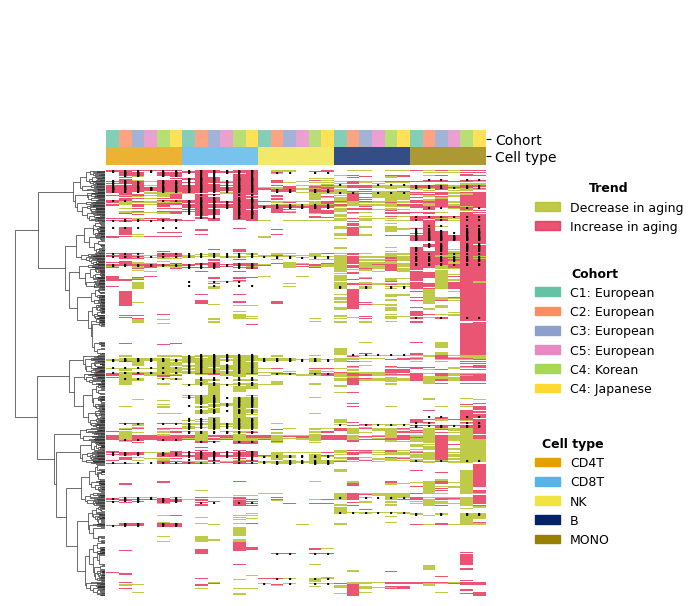

In [3]:
from ciim.src.tf_activity.plots import plot_overall_heatmap


stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor_col2=(1.1, .8),
                    figsize=(6, 8),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Cohort'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Sig TFs counts

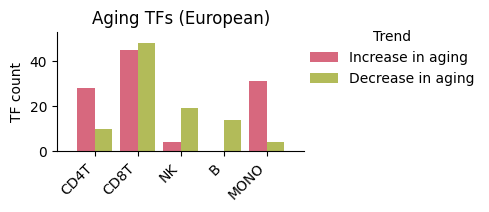

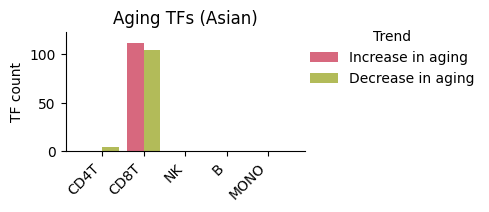

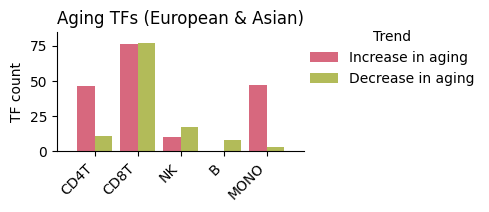

In [5]:
for race in ['european', 'asian', 'both']:
    stats = retrieve_sig_stats(type='bulk', race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
    # plt.savefig(f'../output/tf_activity/trends.png', dpi=300)
    stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
    plot_sig_tfs_stats(stats, figsize=(5, 2))
    plt.title(f'Aging TFs ({surrogate_names[race]})')

## Intersection of races

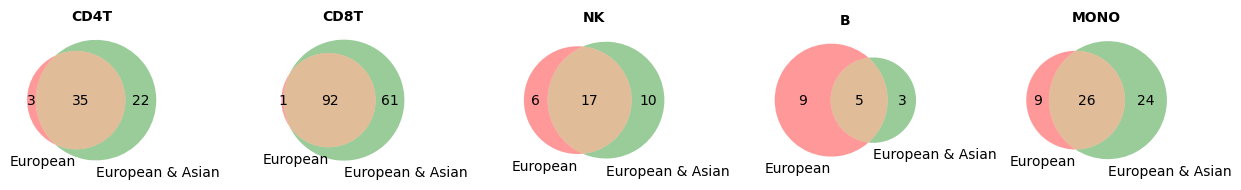

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

type = 'bulk'
# Collect stats as sets of significant TFs for each analysis and cell type
stats_e = retrieve_sig_stats(type, race='european')
stats_a = retrieve_sig_stats(type, race='both')


fig, axes = plt.subplots(1, len(cell_types), figsize=(2.5 * len(cell_types), 2))

if len(cell_types) == 1:
    axes = [axes]

for ax, cell_type in zip(axes, cell_types):

    set_e = set(stats_e[stats_e['cell_type'] == cell_type]['tf'].unique())
    set_a = set(stats_a[stats_a['cell_type'] == cell_type]['tf'].unique())

    v = venn2([set_e, set_a], set_labels=('European', 'European & Asian'), ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(10)
    for text in v.subset_labels:
        if text: text.set_fontsize(10)
    ax.set_title(cell_type, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Cell type specific plots: explicit dataset stats

In [40]:
from ciim.src.tf_activity.helper import retrieve_sig_stats, retrieve_valid_stats
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')

def subset_func(df1, df2, mode_f=np.intersect1d):
    df_store = []
    for cell_type in df1['cell_type'].unique():
        # - subset
        df1_sub = df1[df1['cell_type'] == cell_type]
        df2_sub = df2[df2['cell_type'] == cell_type]
        # - subset
        tfs = mode_f(df1_sub['tf'].unique(), df2_sub['tf'].unique())
        # - subset
        df1_sub = df1_sub[df1_sub['tf'].isin(tfs)]
        df_store.append(df1_sub)
    df1 = pd.concat(df_store)
    return df1

if False:
    stats_sig_1 = retrieve_sig_stats(type, race='european') 
    stats_sig_2 = retrieve_sig_stats(type, race='asian')
    stats_sig = subset_func(stats_sig_1, stats_sig_2, mode_f=np.intersect1d)
else:
    stats_sig = retrieve_sig_stats(type, race='european', filter_inconsistent=False)

tupled_index = stats_sig.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tupled_index].reset_index().drop_duplicates(subset=['cell_type', 'tf', 'dataset'])

# - only keep the consistent ones
# sign_df = stats_all.groupby(['cell_type', 'tf'])['slope'].apply(lambda x: np.sign(x).nunique() == 1)
# tuple_index = sign_df[sign_df].index
# stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

True


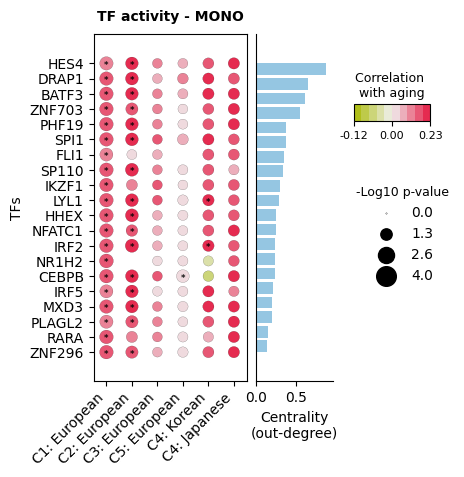

In [41]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

cell_type = 'MONO'
type = 'bulk'
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=None, width=4,
                            feature_type='tf_activity', sizes=(50, 100), min_degree=4, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

## Modularize the interactions

In [10]:
from ciim.src.tf_activity.plots import ModularizedNetPlot
cell_type = 'CD8T'
min_degree = 3
race='european'
type='bulk'

net = ModularizedNetPlot.prepare_net_only_tfs(cell_type, race, type, min_degree)
collapsed_net = ModularizedNetPlot.collapse_nets(net)
collapsed_net = ModularizedNetPlot.add_trend_to_collapsed_net_only_tfs(collapsed_net, type, race, cell_type)
collapsed_net.head()

,source,target,weight,trend_source,trend_target
0,ASCL2,BATF,1.0,Increase in aging,Increase in aging
1,ASCL2,FOXP1/MYC,-1.0,Increase in aging,Decrease in aging
2,BCL11B/PLAG1/TFAP4,FOXP1/MYC,1.0,Decrease in aging,Decrease in aging
3,BCL11B/PLAG1/TFAP4,LEF1/SATB1,1.0,Decrease in aging,Decrease in aging
4,BHLHE40/IRF1,AKNA/PRDM1,1.0,Increase in aging,Increase in aging


In [11]:
collapsed_net.to_csv(f'../output/nets/collapsed_net_{cell_type}.csv', index=False)

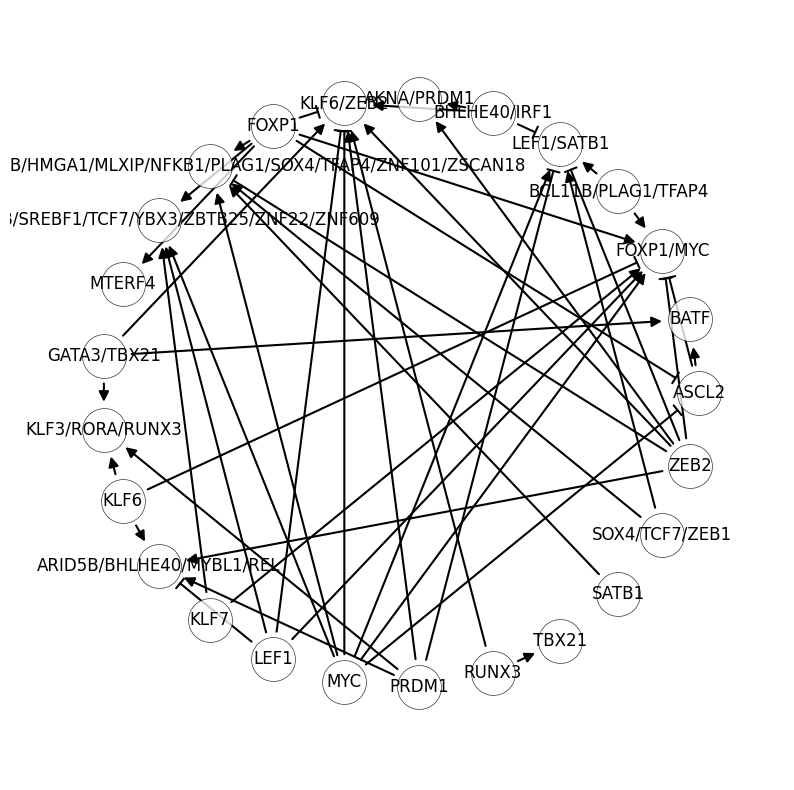

In [12]:
figsize = (10, 10)
draw_evidence = False
offset_evidence = 0.1
arc_offset = 0.05
plot_net_nx(collapsed_net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)

In [13]:
!ls /home/jnourisa/projs/ongoing/ciim/output/sig_nets/

sig_nets_bulk_asian.csv  sig_nets_bulk_both.csv  sig_nets_bulk_european.csv


In [14]:
from ciim.src.tf_activity.plots import ModularizedNetPlot
cell_type = 'CD8T'
min_degree = 3
race='both'
type='bulk'

net = retrieve_sig_net(type, race, cell_type=cell_type)
collapsed_net = ModularizedNetPlot.collapse_nets(net)
collapsed_net = ModularizedNetPlot.add_trend_to_collapsed_net(collapsed_net, net)
collapsed_net.head()

NameError: name 'retrieve_sig_net' is not defined

In [205]:
collapsed_net.to_csv(f'../output/nets/collapsed_sig_net_{cell_type}.csv', index=False)

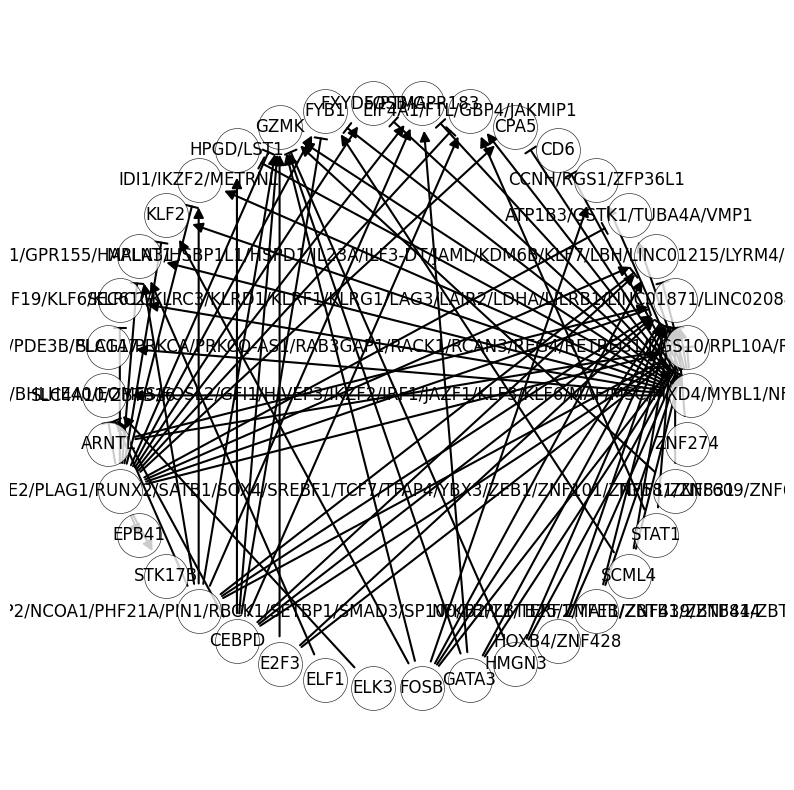

In [204]:
figsize = (10, 10)
draw_evidence = False
offset_evidence = 0.1
arc_offset = 0.05
plot_net_nx(collapsed_net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)

## Identify sig networks

In [5]:
from ciim.src.tf_activity.helper import determine_sig_network

type = 'bulk'

if True:
    for race in ['european','both']:
        determine_sig_network(type, race, min_degree=3)

In [175]:
from ciim.src.tf_activity.helper import retrieve_sig_net
cell_type = 'CD8T'
type = 'bulk'
race = 'both'
tfs = ['JUND', 'TCF7', 'MYC', 'BACH2']

sig_net = retrieve_sig_net(type, race, cell_type)
sig_net['sign'] = np.sign(sig_net['weight'])
sig_net.shape

(18224, 9)

### Network topology

In [106]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

nets = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')

In [68]:
# nets['cell_type'].unique()

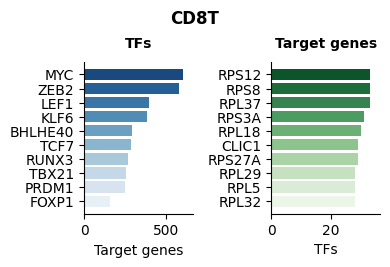

In [107]:
from ciim.src.tf_activity.plots import plot_net_degrees

for cell_type in ['CD8T']:
    net = nets[nets['cell_type'] == cell_type]
    plot_net_degrees(net)
    plt.suptitle(f'{cell_type}', fontsize=12, y=1.05, fontweight='bold')
    

## Interaction of aging TFs between cell types

### T cells

In [9]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

type = 'bulk'
race='both'
stats_sig = retrieve_sig_stats(type=type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)

['CD8T', 'CD4T', 'MONO', 'NK', 'B']


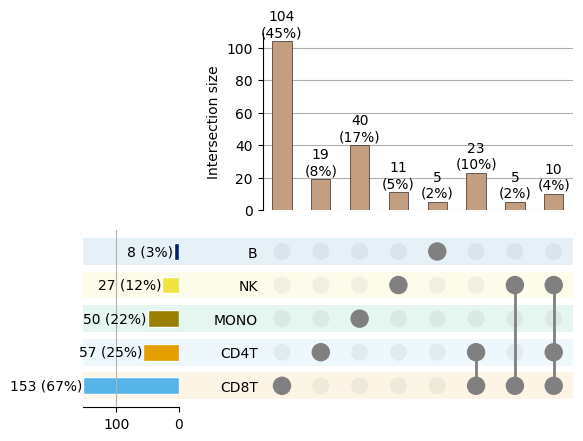

In [10]:
aa = plot_interactions(interaction_main_df, min_subset_size=5, min_degree=1, color_map=palette_cell_types)
# plt.savefig(f'../output/tf_activity/interactions.png', dpi=300)
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

10


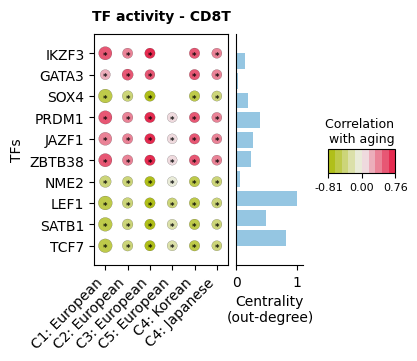

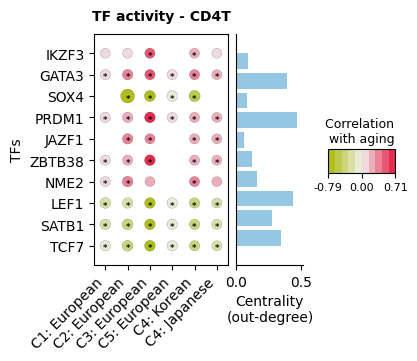

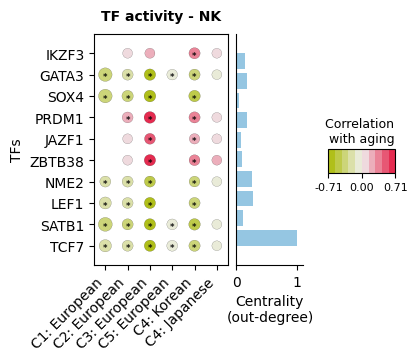

In [11]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, race=race, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

### Shared sig TFs between CD8T and CD4T

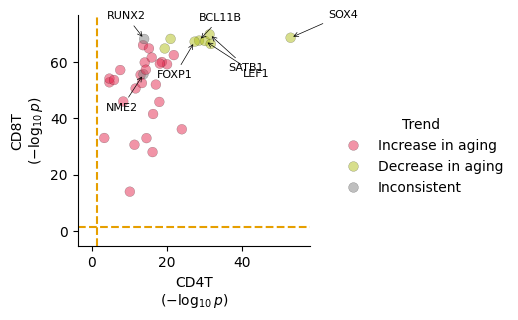

In [14]:
from ciim.src.tf_activity.plots import plot_joint_scatter

ttypes = ['CD8T', 'CD4T']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(features)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

## GSEA

In [7]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
type = 'bulk'
feature_type = 'tf_activity'
races = ['european', 'both']

pathway_scores_store = []
for race in races:
    stats_sig = retrieve_sig_stats(type, race=race)
    
    pathway_scores = pathway_analysis_wrapper(stats_sig)
    pathway_scores['race'] = race
    pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])
    pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

(7, 10)
(3, 10)
(6, 10)
(2, 10)
(4, 10)
(9, 10)
(7, 10)
(1, 10)
(8, 10)
(6, 10)
(3, 10)
(7, 10)
(2, 10)
(8, 10)
(1, 10)
(2, 10)


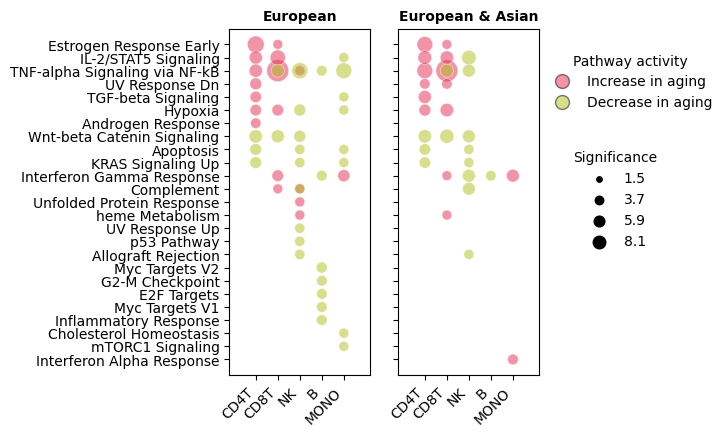

In [8]:
from ciim.src.tf_activity.plots import dotplot_category_color
from ciim.src.common import surrogate_names
    
fig, axes = plt.subplots(1, len(races), figsize=(2*len(races), 4.5), sharey=True, sharex=True)
for i, race in enumerate(races):
    ax = axes[i] if len(races)>1 else axes
    pathway_scores = pathway_scores_all[pathway_scores_all['race']==race]
    pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
    if i == len(races)-1:
        show_color_legend = True
        show_size_legend = True
    else:
        show_color_legend = False
        show_size_legend = False
    dotplot_category_color(pathway_scores, 
                ax, 
                color_col='trend', 
                size_col='neg_log10_adj_pval', 
                x='cell_type', 
                y='Term', 
                palette=palette_trend_2, sizes=(50, 250),
                show_color_legend=show_color_legend, 
                show_size_legend=show_size_legend,
                size_legend_title='Significance',
                color_legend_title='Pathway activity',
                size_legend_loc=(1.2, 0.35),
                color_legend_loc=(1.02, 0.75),
                y_label='',
                alpha=0.5)
    ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [9]:
pathway_scores['Term'].unique()

array(['TNF-alpha Signaling via NF-kB', 'Estrogen Response Early',
       'IL-2/STAT5 Signaling', 'TGF-beta Signaling', 'Hypoxia',
       'UV Response Dn', 'Wnt-beta Catenin Signaling', 'Apoptosis',
       'KRAS Signaling Up', 'Interferon Gamma Response',
       'heme Metabolism', 'Complement', 'Allograft Rejection',
       'Interferon Alpha Response'], dtype=object)

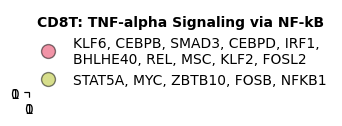

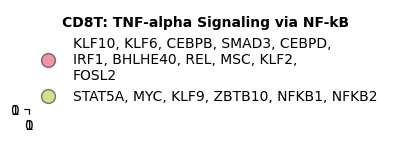

In [10]:
# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'CD8T'

from ciim.src.tf_activity.plots import plot_term_genes
for race in races:
    pathway_scores = pathway_scores_all[pathway_scores_all['race']==race]
    plot_term_genes(pathway_scores, cell_type, term)


In [11]:
from ciim.src.utils.util import get_genesets
pathways = get_genesets()
for key in pathways.keys():
    if 'STAT5' in key:
        print(key)
len(pathways['HALLMARK_IL2_STAT5_SIGNALING'])

HALLMARK_IL2_STAT5_SIGNALING


199

In [12]:
features = pathway_scores_all[(pathway_scores_all['Term']==term) & (pathway_scores_all['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()


True


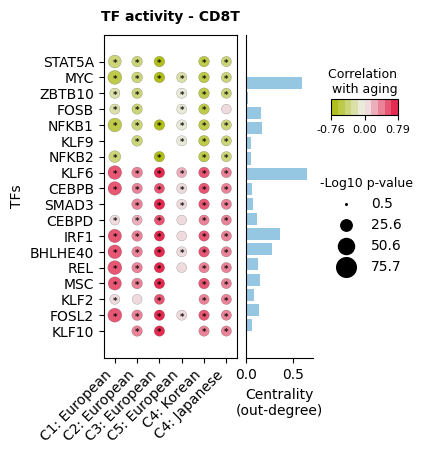

In [13]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


# Minor cell types

## Heatmap

In [107]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
race='both'
stats_store = []
for type in ['bulk', 'bulk_minor']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy', race=race)

    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add sig flags
    stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)

    stats_tf['major_cell_type'] = stats_tf['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['major_cell_type', 'cell_type', 'tf', 'slope', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf'])

# - plot
stats_all_combined['major_cell_type'] = stats_all_combined['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))


In [108]:
ordered_cell_names = ['CD4T',
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'CD8T',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'B',
                    'Memory_B',
                    'Naive_B',
                    ]
stats_all_combined['cell_type'] = pd.Categorical(stats_all_combined['cell_type'], categories=ordered_cell_names, ordered=True)

['#E52B50', '#B0BF1A']


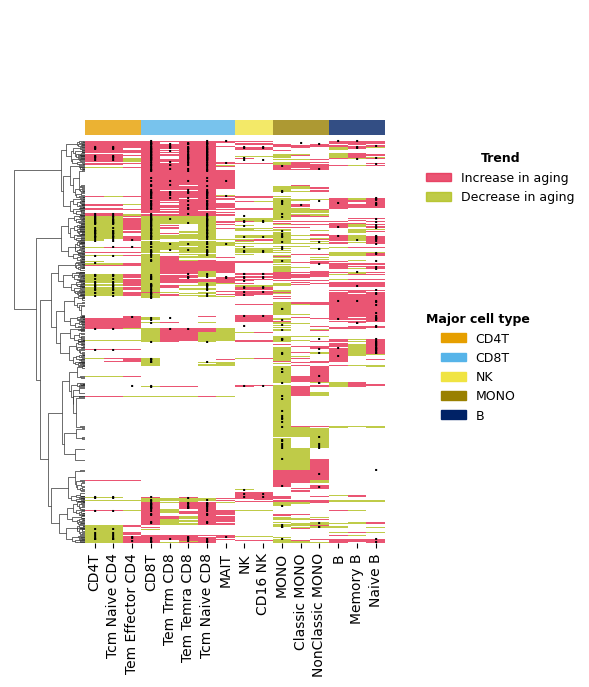

In [ ]:
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
heamap_plot_minor_cell_types(stats_all_combined, slope_col='slope', palette=palette_trend_2, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

## Pathways

In [65]:
type = 'bulk_minor'
race = 'both'
stats_sig = retrieve_sig_stats(type=type, race=race)

pathway_scores = pathway_analysis_wrapper(stats_sig)

(1, 10)
(1, 10)
(3, 10)
(6, 10)
(1, 10)
(3, 10)
(2, 10)
(3, 10)
(2, 10)
(4, 10)
(7, 10)
(1, 10)
(6, 10)
(4, 10)
(3, 10)
(5, 10)


In [66]:
ordered_minors = ['Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',
                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'Memory_B',
                    'Naive_B',]
ordered_minors = [item.replace('_', ' ') for item in ordered_minors]
pathway_scores['cell_type_pretty'] = pathway_scores['cell_type'].str.replace('_', ' ')
pathway_scores['cell_type_pretty'] = pd.Categorical(pathway_scores['cell_type_pretty'], categories=ordered_minors, ordered=True)
pathway_scores = pathway_scores[~pathway_scores['cell_type_pretty'].isna()]


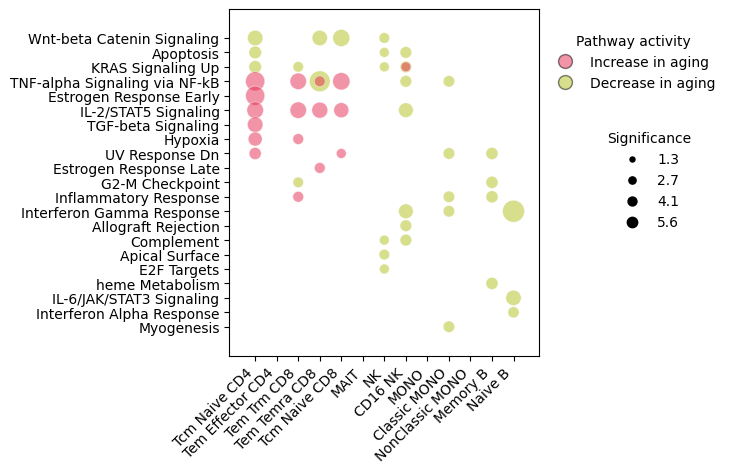

In [67]:
pathway_scores['neg_log10_adj_pval'] = -np.log10(pathway_scores["FDR"])
fig, ax = plt.subplots(1, 1, figsize=(4, 4.5))    

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='trend', 
            size_col='neg_log10_adj_pval', 
            x='cell_type_pretty', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.2, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)
ax.margins(x=.1, y=.1)
# ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [70]:
pathway_scores['Term'].unique()

array(['Wnt-beta Catenin Signaling', 'Apoptosis', 'KRAS Signaling Up',
       'TNF-alpha Signaling via NF-kB', 'Estrogen Response Early',
       'IL-2/STAT5 Signaling', 'TGF-beta Signaling', 'Hypoxia',
       'UV Response Dn', 'Estrogen Response Late', 'G2-M Checkpoint',
       'Inflammatory Response', 'Interferon Gamma Response',
       'Allograft Rejection', 'Complement', 'Apical Surface',
       'E2F Targets', 'heme Metabolism', 'IL-6/JAK/STAT3 Signaling',
       'Interferon Alpha Response', 'Myogenesis'], dtype=object)

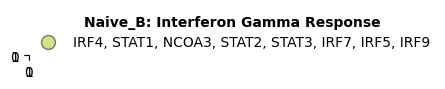

In [71]:
from ciim.src.tf_activity.plots import plot_term_genes
term= 'Interferon Gamma Response' #'TNF-alpha Signaling via NF-kB' 
plot_term_genes(pathway_scores, cell_type='Naive_B', term=term)
# plot_term_genes(pathway_scores, cell_type='Tcm_Naive_CD8', term=term)

No data for Tcm_Naive_CD8 source


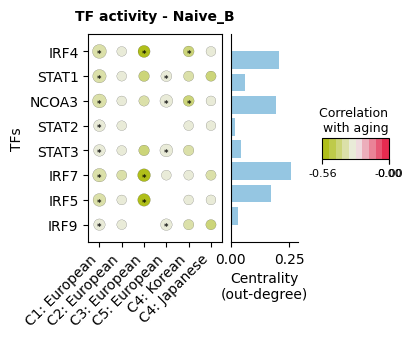

In [72]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
for cell_type in ['Naive_B', 'Tcm_Naive_CD8']:
    features = pathway_scores[(pathway_scores['Term']==term) & (pathway_scores['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()

    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                    feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


## Interaction of subtypes

['Tcm_Naive_CD8', 'Tem_Temra_CD8', 'Tem_Trm_CD8']


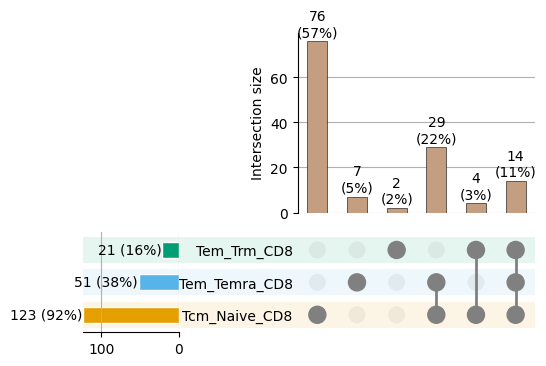

In [22]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
type = 'bulk_minor'
race = 'both'

minor_types = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8',]

stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig = stats_sig[stats_sig['cell_type'].isin(minor_types)]
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=2, color_map=None)

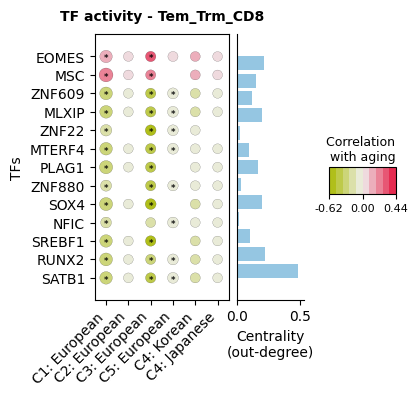

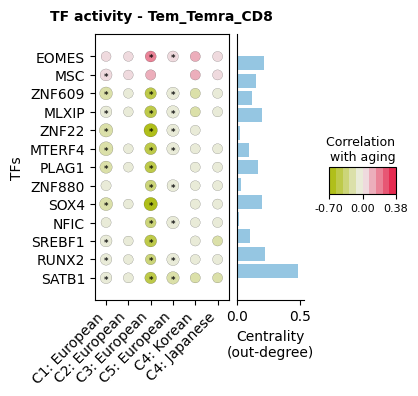

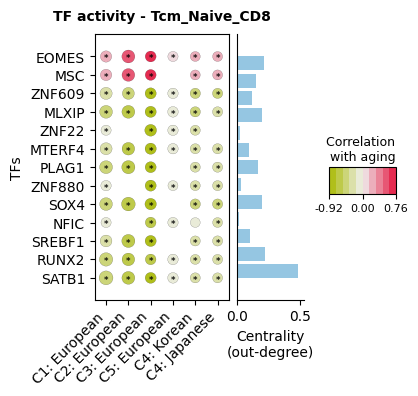

In [23]:
# - shared features
from ciim.src.tf_activity.plots import plot_features_vs_datasets
# - plot the common ones
features = interaction_main_df[interaction_main_df.sum(axis=1)==3].index
for cell_type in minor_types:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)


In [17]:
stats_sig['cell_type'].unique()

array(['Tcm_Naive_CD8', 'Tem_Temra_CD8', 'Tem_Trm_CD8'], dtype=object)

(18,)


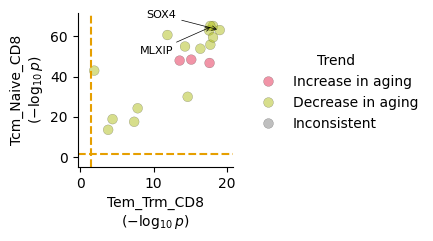

In [18]:
from ciim.src.tf_activity.plots import plot_joint_scatter

vars = ['Tem_Trm_CD8',
                'Tcm_Naive_CD8']
interaction_main_ts_df = interaction_main_df[vars]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=vars, annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

True


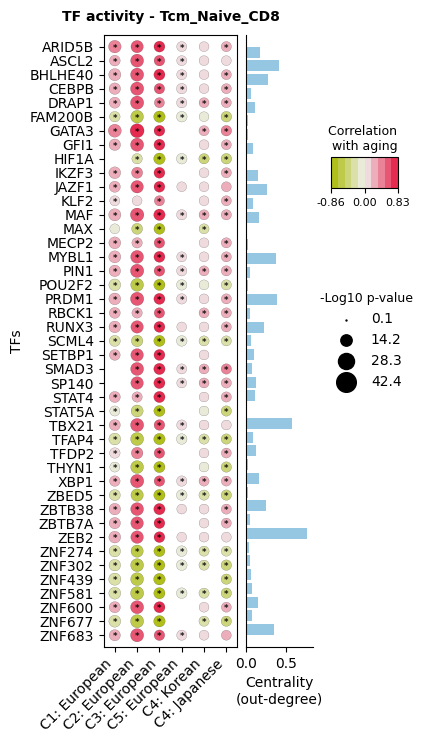

In [25]:
# - unique to one minor cell type
cell_type = 'Tcm_Naive_CD8'
unique_interactions = interaction_main_df[interaction_main_df.sum(axis=1)==1]
features = unique_interactions[unique_interactions[cell_type]].index
features = np.sort(features)
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True, margins={'x': 0.1, 'y': 0.02})

# Gender


## Overall plot

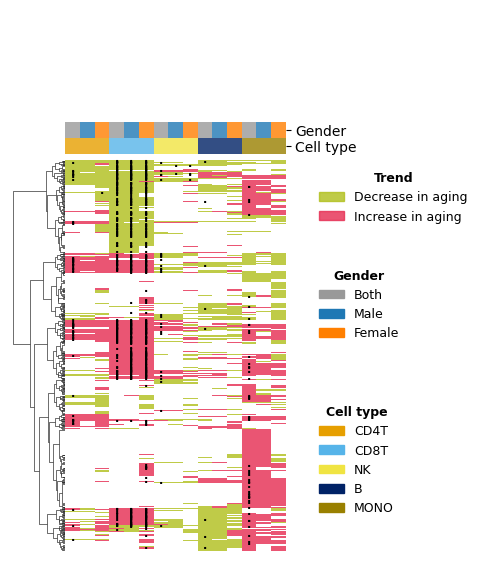

In [8]:
# - get the stats for bulk of both gender
from ciim.src.tf_activity.helper import retrieve_stats_features
stats_store = []
race='both'

for type in ['bulk', 'bulk_M', 'bulk_F']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy', race=race)
    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add valid cases
    stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)
    
    # stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_sig['tf'])) & (stats_tf['cell_type'].isin(stats_sig['cell_type']))
    
    stats_tf['gender'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'gender', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'gender', 'is_significant'])

# - plot
stats_all_combined['gender'] = stats_all_combined['gender'].map({'bulk': 'Both', 'bulk_F': 'Female', 'bulk_M': 'Male'}).astype(CategoricalDtype(categories=['Both', 'Male', 'Female'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=3, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='gender', second_col_palette={**{'Both': 'gray', **palette_genders}},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'gender': 'Gender'})

In [47]:
# stats_all_combined[stats_all_combined['cell_type']=='MONO']['tf'].nunique()

527

## Interactions

In [9]:
race = 'both'
stats_sig_M  = retrieve_sig_stats(type='bulk_M', race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_M['gender'] = 'Male'
stats_sig_F = retrieve_sig_stats(type='bulk_F', race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_F['gender'] = 'Female'
stats_sig_all = pd.concat([stats_sig_M, stats_sig_F])


if True:
    # - find tfs with opposite trends
    features_dict = {}
    for cell_type in cell_types:
        stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]
        mask = stats_t.groupby('tf')['slope'].apply(lambda x: np.sign(x).nunique() == 2)
        tfs = mask[mask].index.tolist()
        features_dict[cell_type] = tfs

    print('tfs with opposite trends: ', features_dict)

# - find tfs sig in one gender and not the other
features_dict = {}
for cell_type in ['CD8T']:
    stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]  
    sig_tfs_M = stats_t[stats_t['gender']=='Male']['tf'].unique()
    sig_tfs_F = stats_t[stats_t['gender']=='Female']['tf'].unique()
    features_dict[cell_type] = np.setxor1d(sig_tfs_M, sig_tfs_F)
    # print(features_dict[cell_type])
    # aa

print('tfs sig in one and not the other: ', features_dict)

tfs with opposite trends:  {'CD4T': [], 'CD8T': [], 'NK': [], 'B': [], 'MONO': []}
tfs sig in one and not the other:  {'CD8T': array(['AHR', 'CREM', 'FLI1', 'HMGN3', 'JUNB', 'KLF2', 'MAFF', 'MXI1',
       'NFIC', 'NR1H2', 'RELB', 'SNAI1', 'ZNF267', 'ZNF331', 'ZNF740'],
      dtype=object)}


In [5]:
stats_all = pd.read_csv(f'../output/tf_activity/stats_all_bulk_M.csv')
mask = (stats_all['condition']=='healthy') & (stats_all['cell_type']=='CD8T') & (stats_all['tf']=='AHR')
stats_all[mask]

,tf,p_value,slope,p_value_adj,condition,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,trend,race
851,AHR,0.005517,-0.340477,0.006943,healthy,data13_Japanese,CD8T,0.005517,0.007411,2.130114,Decrease in aging,both
1182,AHR,0.003669,-0.358090,0.004644,healthy,data13_Korean,CD8T,0.005517,0.007411,2.130114,Decrease in aging,both


True
True


Text(0.5, 1.1, 'Male')

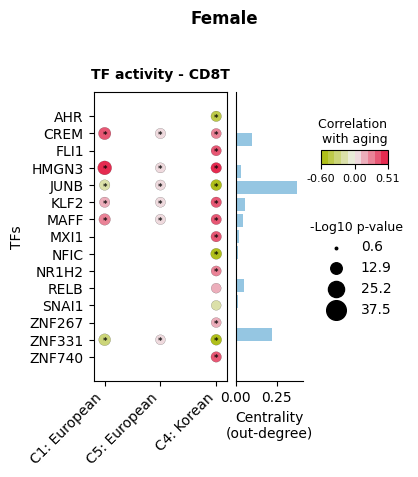

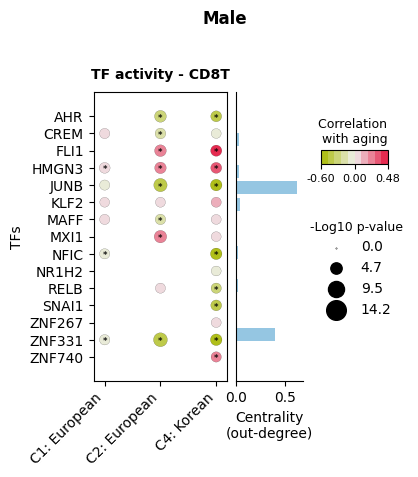

In [12]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
cell_type='CD8T'

features = features_dict[cell_type]
datasets = ['data1', 'SLE_European', 'data13_Korean']
plot_features_vs_datasets(cell_type=cell_type, type='bulk_F', datasets=datasets, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Female', fontsize=12, y=1.1, fontweight='bold')
datasets = ['data1', 'data7_allTPs_jalil', 'data13_Korean']
plot_features_vs_datasets(cell_type=cell_type, type='bulk_M', datasets=datasets, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Male', fontsize=12, y=1.1, fontweight='bold')

# SLE


## Overview

In [85]:
ordered_cell_names = [
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'Tcm_Naive_CD8',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',

                    'Classic_MONO',
                    'NonClassic_MONO',
                    
                    'Naive_B',
                    'Memory_B',
                    ]

In [86]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
race='both'
type = 'bulk_minor'
dataset = 'SLE'
stats_tfs = pd.read_csv(f'../output/tf_activity/stats_features_{type}.csv')
stats_sle = stats_tfs[(stats_tfs['dataset'].str.contains(dataset)) & (~stats_tfs['slope_condition'].isna())].copy()
stats_sle = stats_sle[stats_sle['cell_type'].isin(ordered_cell_names)]
stats_sle = stats_sle[stats_sle['p_value_adj'] < 0.05].copy()
stats_sle['major_cell_type'] = stats_sle['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
stats_sle.head()

,tf,p_value,slope,p_value_adj,condition,dataset,cell_type,slope_condition,ctrl,major_cell_type
1912,ARID5B,2.478398e-15,NaN,1.689817e-14,SLE,SLE_European,Tcm_Naive_CD4,2.400157,normal,CD4T
1913,ASH1L,2.568091e-02,NaN,3.320807e-02,SLE,SLE_European,Tcm_Naive_CD4,-0.023495,normal,CD4T
1915,BACH2,4.144783e-05,NaN,6.344056e-05,SLE,SLE_European,Tcm_Naive_CD4,-0.108298,normal,CD4T
1916,BATF,4.011776e-15,NaN,2.314486e-14,SLE,SLE_European,Tcm_Naive_CD4,0.888701,normal,CD4T
1917,BCL11B,4.281503e-05,NaN,6.422255e-05,SLE,SLE_European,Tcm_Naive_CD4,-0.164478,normal,CD4T


In [88]:
stats_sle['major_cell_type'] = stats_sle['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))
stats_sle['cell_type'] = pd.Categorical(stats_sle['cell_type'], categories=ordered_cell_names, ordered=True)

['#0072B2', 'Orange']


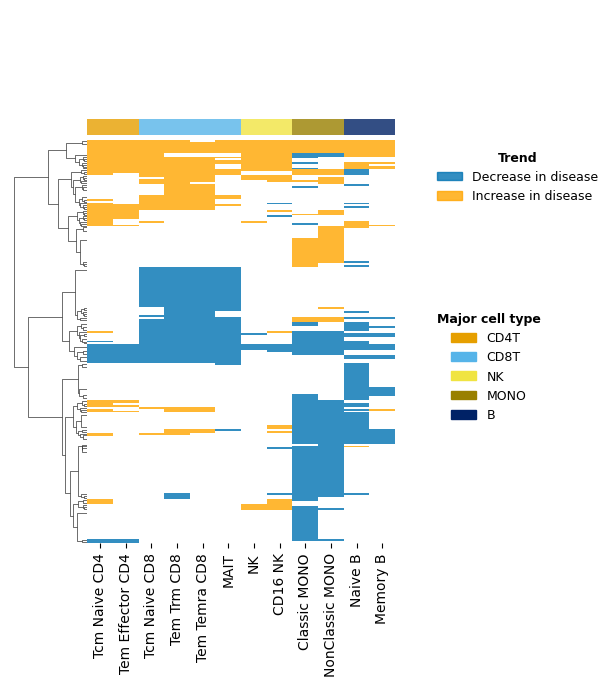

In [106]:
# - plot
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
from ciim.src.common import palette_disease_effect
heamap_plot_minor_cell_types(stats_sle, slope_col='slope_condition', palette=palette_disease_effect, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

## Aging TFs and SLE

In [46]:
type = 'bulk_minor'
stats_sig = retrieve_sig_stats(type, race='both').drop_duplicates(subset=['cell_type', 'tf'])

def retrieve_sle(type):
    dataset = 'SLE'
    stats_tfs = pd.read_csv(f'../output/tf_activity/stats_features_{type}.csv')
    stats_sle = stats_tfs[stats_tfs['dataset'].str.contains(dataset)].copy()
    stats_sle = stats_sle[stats_sle['p_value_adj'] < 0.05].copy()
    return stats_sle
stats_sle = retrieve_sle(type)

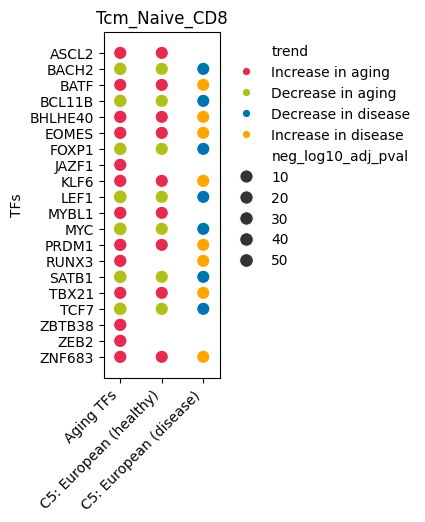

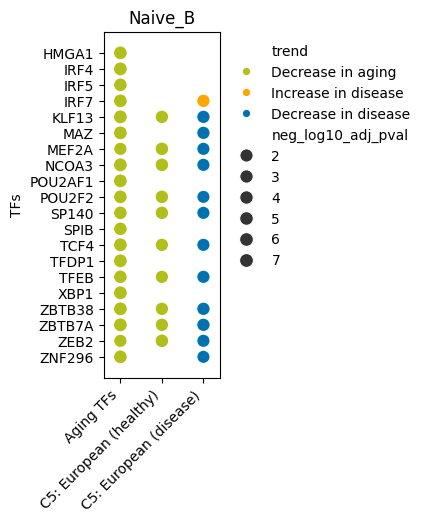

In [48]:
from ciim.src.common import palette_trend, palette_disease_effect
top_aging_tfs = 20

palette_all = {**palette_trend, **palette_disease_effect}
stats_sle['dataset'] = stats_sle['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in ['Tcm_Naive_CD8', 'Naive_B']:
    # - validation
    aging_df = stats_sig[stats_sig['cell_type']==cell_type]
    net = get_consensus_net(datasets_all, cell_type, min_degree=3)
    c_df = net.groupby('source').size().reset_index(name='degree')
    aging_df = aging_df.merge(c_df, left_on='tf', right_on='source', how='left')


    aging_df['analysis'] = 'Aging TFs'
    top_tfs = aging_df.sort_values('degree', ascending=False).head(top_aging_tfs)['tf'].unique() # change this to centrality

    # - aging
    stats_sotre = []
    for d in stats_sle['dataset'].unique():
        stats_h = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'healthy') & (~stats_sle['slope'].isna())].copy()
        stats_h['analysis'] = d + ' (healthy)'
        stats_h['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in stats_h['slope']]
        stats_sotre.append(stats_h)
    
    # - disease
    for d in stats_sle['dataset'].unique():
        stats_d = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'SLE') & (~stats_sle['slope_condition'].isna())].copy()

        stats_d['analysis'] = d + ' (disease)'
        stats_d['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_a = pd.concat(stats_sotre)


    stats_combined = pd.concat([aging_df, stats_a])
    df = stats_combined[stats_combined['tf'].isin(top_tfs)]
    
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    

    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4.5))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, size='neg_log10_adj_pval', sizes=(90, 100))
    ax.margins(x=.2, y=.07)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    plt.title(f'{cell_type}')

Text(0.5, 1.4, 'TCM Naive CD8T (ZEB2)')

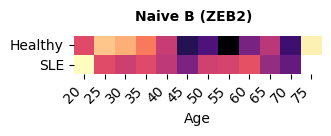

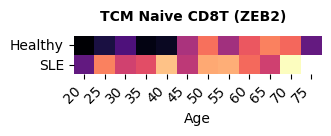

In [79]:
from ciim.src.tf_activity.plots import heatplot_age_trend
from collections import defaultdict
from ciim.src.common import surrogate_names


def format_tf_activity_for_disease_trend_plot(dataset, cell_type, tf, age_limit=[20, 75]):
    tf_acts = retrieve_feature_data(dataset, cell_type, type='bulk')
    tf_acts = tf_acts[(tf_acts.obs['age'] >= age_limit[0]) & (tf_acts.obs['age'] <= age_limit[1])]
    tf_acts = tf_acts[:, tf_acts.var_names == tf]
    if tf_acts.shape[1]==0:
        return None

    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr['disease'] = expr['disease'].astype('category')
    expr['age'] = expr['age'].astype(int)

    # Pivot table: rows = disease, columns = age, values = expression
    expr_table = expr.pivot_table(index='disease', columns='age', values=tf)

    # Bin ages into 5-year intervals
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = defaultdict(list)

    for col in age_columns:
        bin_start = (col // 5) * 5
        age_bins[bin_start].append(col)

    # Average across bins
    binned_means = {bin_start: df[bin_ages].mean(axis=1) for bin_start, bin_ages in age_bins.items()}
    binned_df = pd.DataFrame(binned_means)

    # Sort bins by age
    binned_df = binned_df[sorted(binned_df.columns)]
    
    return binned_df

def plot_healthy_disease_trend(cell_type, case_tf):
    binned_df = format_tf_activity_for_disease_trend_plot(dataset, cell_type, tf=case_tf)
    binned_df.index = [surrogate_names.get(name, name) for name in binned_df.index]
    fig, ax = plt.subplots(1, 1, figsize=(3.2, .5), sharey=False, sharex=True)
    heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF \n activity", y_label="Condition", ax=ax, show_cbar=False, shrink=1)
    ax.set_xlabel('Age')
case_tf = 'ZEB2'
cell_type = 'Naive_B'
plot_healthy_disease_trend(cell_type=cell_type, case_tf=case_tf)
plt.suptitle(f'{surrogate_names[cell_type]} ({case_tf})', fontsize=10, fontweight='bold', y=1.4)

case_tf = 'ZEB2'
cell_type = 'Tcm_Naive_CD8'
plot_healthy_disease_trend(cell_type=cell_type, case_tf=case_tf)    
plt.suptitle(f'{surrogate_names[cell_type]} ({case_tf})', fontsize=10, fontweight='bold', y=1.4)

# Drug perturbation

In [16]:
from ciim.src.tf_activity.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
type = 'bulk'
test_type= 'paired' #'mixed-effect'
dataset = 'CXCL9'
feature_type= 'tf_activity' #'tf_activity' gene_expression


if False:
    if feature_type == 'tf_activity':
        wrapper_tf_activity(cell_types, datasets=[dataset], type=type)
    else:
        wrapper_gene_expression(cell_types, datasets=[dataset], type=type)

    par = {
            'type': type,
            'cell_type_resolution': 'Major_CT',
        }
    stats_all = wrapper_association_with_age_condition(par, cell_types, datasets=[dataset], feature_type=feature_type, features=None, test_type=test_type)
    stats_all.to_csv(f'../output/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
else:
    stats_all = pd.read_csv(f'../output/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')
    

## Overview

In [ ]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'LPS+Metformin',
    '24 h LPS + metformin + ruxolitinib': 'LPS+Met.+Rux.', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Metformin',
    '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met.+Rux.',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux.',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}

In [19]:
# - stats of RMPI and LPs as controls
stats_store = []
stats = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h RPMI + metformin', '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib']))] 
stats_store.append(stats)

stats = stats_all[(stats_all['ctrl']=='24 h LPS') & (stats_all['condition'].isin(['24 h LPS + metformin', '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib']))] 
stats_store.append(stats)

stats = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h LPS']))] 
stats_store.append(stats)

stats_drugs = pd.concat(stats_store, axis=0)
stats_drugs['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_drugs['slope_condition']]
ctrls = stats_drugs['ctrl'].unique()

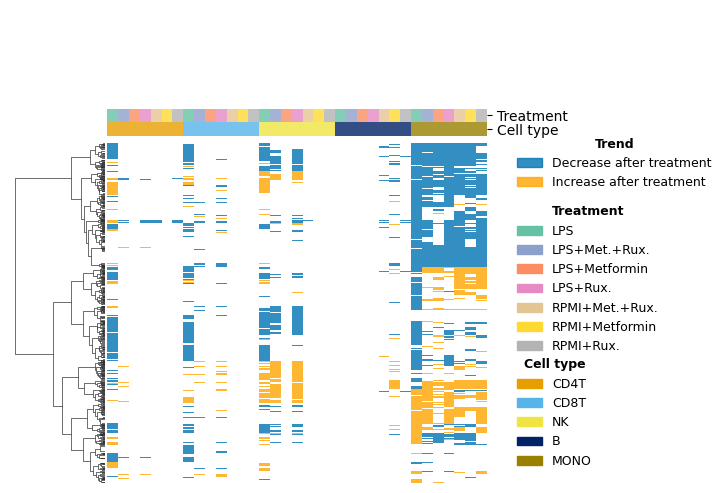

In [18]:
from ciim.src.tf_activity.plots import plot_overall_heatmap
from ciim.src.common import palette_treatment, palette_cell_types

stats_all_c = stats_drugs.copy()

stats_all_c['condition'] = stats_all_c['condition'].replace(pretty_names)
stats_all_c = stats_all_c[~stats_all_c['condition'].isna()]
stats_all_c = stats_all_c.rename(columns={'slope_condition': 'slope'})

stats_all_c['cell_type'] = pd.Categorical(stats_all_c['cell_type'], categories=cell_types, ordered=True)
stats_all_c['condition'] = stats_all_c['condition'].astype('category')

stats_all_c = stats_all_c[stats_all_c['p_value_adj'] < 0.05]

# stats_all_c['condition'] = pd.Categorical(stats_all_c['condition'], categories=pretty_names.values(), ordered=True)
# stats_all_c['is_significant'] = stats_all_c['p_value_adj'] < 0.05
stats_all_c.rename(columns={'target': 'tf'}, inplace=True)
plot_overall_heatmap(stats_all_c, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='condition', second_col_palette={value: color for value, color in zip(pretty_names.values(), sns.color_palette("Set2", n_colors=len(pretty_names.values())) )},
                    trend_colors = list(palette_treatment.values()),
                    trend_names = list(palette_treatment.keys()),
                    bbox_to_anchor=(1.05, 1.05),
                    bbox_to_anchor_col1=(1.05, .4),
                    bbox_to_anchor_col2=(1.05, .85),
                    figsize=(6, 7),
                    map_names={**{'cell_type':'Cell type', 'condition': 'Treatment'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

In [10]:
from ciim.src.tf_activity.plots import plot_sig_tfs_stats

conditions = stats_drugs['condition']
fig, axes = plt.subplots(2, len(conditions), figsize=(9, 4), sharey=True, sharex=False)

j = 0
for ctrl in ctrls:
    i = 0
    for treatment in stats_drugs['condition'].unique():
        stats = stats_drugs[(stats_drugs['ctrl'] == ctrl) & (stats_drugs['condition'] == treatment)  & (stats_drugs['p_value_adj']<0.05)]
        if len(stats) == 0:
            continue
        ax = axes[j, i]
        i += 1
        
        stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
        plot_sig_tfs_stats(stats, figsize=(5, 2), palette=palette_treatment, ax=ax)
        ax.get_legend().remove()
        ax.set_title(f'{pretty_names[treatment] }')
    
    j += 1
ax.legend(loc=(1.1, 0.5), title='Trend', frameon=False)

KeyboardInterrupt: 

## Aging TFs

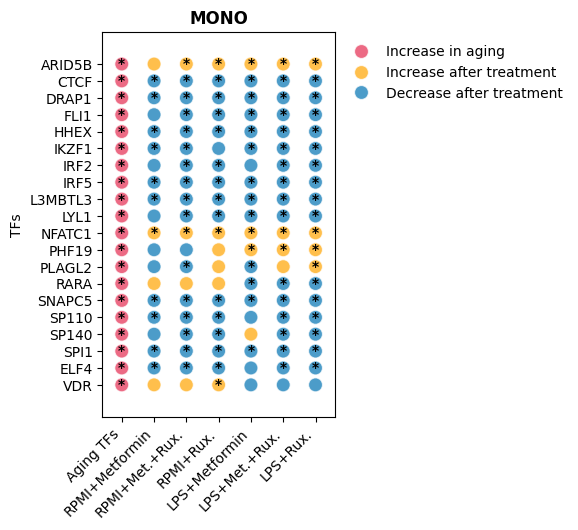

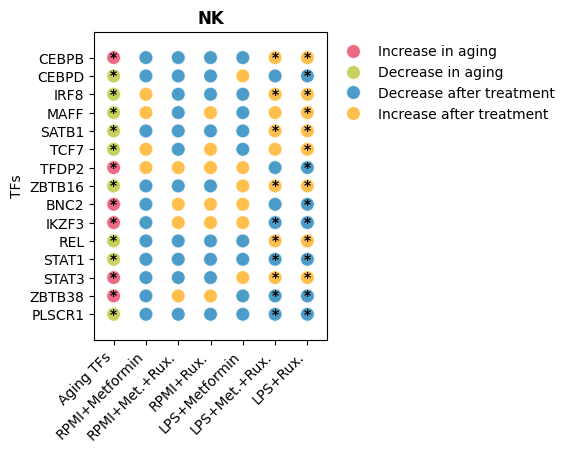

In [12]:
from ciim.src.common import palette_trend, palette_treatment
palette_all = {**palette_trend, **palette_treatment}
# stats_RPMI_ctr['dataset'] = stats_RPMI_ctr['dataset'].apply(lambda name: surrogate_names.get(name, name))
stats_df = stats_drugs.copy()

type = 'bulk'
race = 'both'
top_aging_tfs = 20

for cell_type in ['MONO', 'NK']:
    # - aging tfs
    stats_aging  = retrieve_sig_stats(type=type, race=race).drop_duplicates(subset=['tf', 'cell_type'])
    stats_aging = stats_aging[stats_aging['cell_type']==cell_type]
    stats_aging['analysis'] = 'Aging TFs'

    # - drugs
    stats_sotre = []
    for d in stats_df['condition'].unique():
        stats_d = stats_df[(stats_df['condition'] == d) & (stats_df['cell_type'] == cell_type)].copy()
        stats_d['is_significant'] = stats_d['p_value_adj'] < 0.05

        stats_d['analysis'] = d 
        stats_d['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_d = pd.concat(stats_sotre)
    # - subset the aging tfs to the drugs
    stats_d_sig = stats_d[stats_d['p_value_adj'] < 0.05]
    drug_tfs = stats_d_sig['tf'].unique()
    agings_tfs = stats_aging['tf'].unique()
    common_tfs = np.intersect1d(drug_tfs, agings_tfs)

    # - merge
    df = pd.concat([stats_aging, stats_d])
    df = df[df['tf'].isin(common_tfs)]
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    # - subset the tfs
    if True:
        net = get_consensus_net(datasets_all, cell_type, min_degree=3)
        c_df = net.groupby('source').size().reset_index(name='degree')
        df_merged = df.merge(c_df, left_on='tf', right_on='source', how='left')

        top_tfs = df_merged.drop_duplicates(subset=['cell_type', 'tf']).sort_values('degree', ascending=False).head(top_aging_tfs)['tf'].unique() # change this to centrality
        df = df[df['tf'].isin(top_tfs)]
    
    fig, ax = plt.subplots(1, 1, figsize=(3,len(top_tfs)*.2 + 1))
    df['analysis'] = df['analysis'].apply(lambda name: pretty_names.get(name, name))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, 
                    s=100 , 
                    # sizes=(50, 100), 
                    alpha=.7)
    ax.margins(x=.1, y=.1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    # Add significance annotation (e.g., a dot or asterisk) to significant points
    for _, row in df.iterrows():
        if row.get('is_significant', False):  # Ensure this column exists
            ax.text(
                x=row['analysis'],
                y=row['tf'],
                s='*',  # or '.' or '★'
                color='black',
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )
    plt.title(f'{cell_type}', fontsize=12, fontweight='bold')

## Pathway analysis

In [142]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
pathway_scores_store = []
for ctr in stats_drugs['ctrl'].unique():
    for treatment in stats_drugs['condition'].unique():
        stats_sig = stats_drugs[(stats_drugs['ctrl'] == ctr) & (stats_drugs['condition'] == treatment) & (stats_drugs['p_value_adj'] < 0.05)]
        if len(stats_sig) == 0:
            continue
        pathway_scores = pathway_analysis_wrapper(stats_sig, pvalue_col='p_value_adj')
        if pathway_scores is None:
            continue
        pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])
        pathway_scores['ctrl'] = ctr
        pathway_scores['condition'] = treatment
        pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

(1, 10)
(2, 10)
(3, 10)
(3, 10)
(3, 10)
(8, 10)
(3, 10)
(6, 10)
(6, 10)
(4, 10)
(6, 10)
(4, 10)
(6, 10)
(5, 10)
(7, 10)
(10, 10)
(3, 10)
(5, 10)
(1, 10)
(2, 10)
(9, 10)
(3, 10)
(2, 10)
(6, 10)
(3, 10)
(6, 10)
(7, 10)
(3, 10)
(4, 10)
(1, 10)
(2, 10)
(8, 10)
(3, 10)
(7, 10)


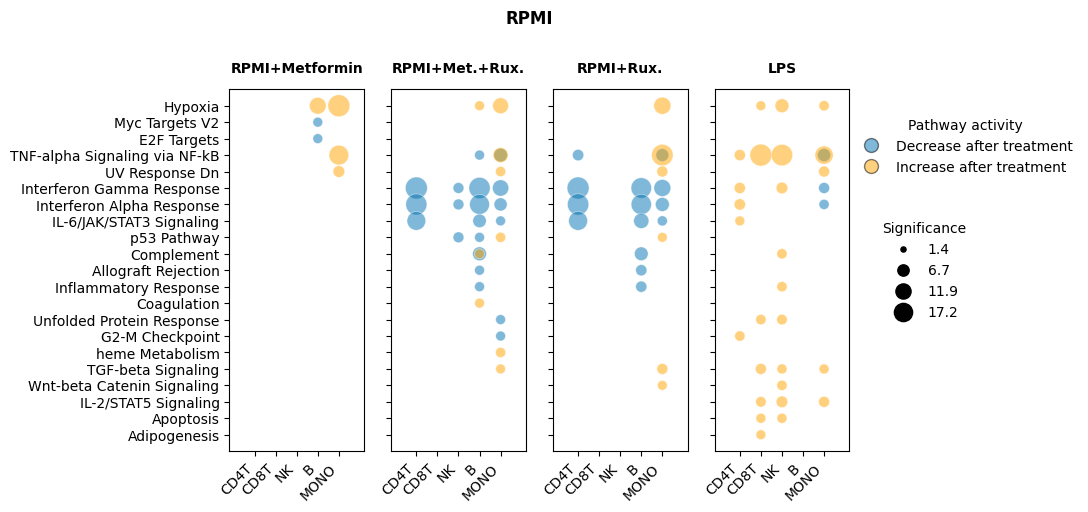

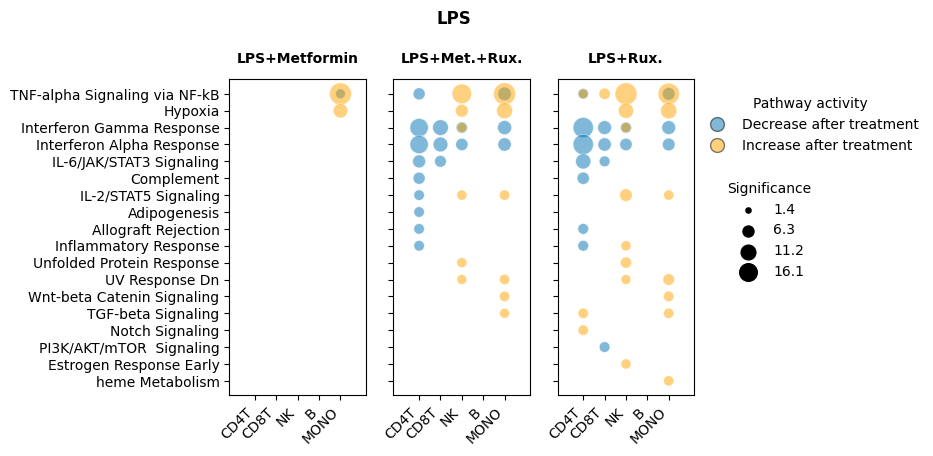

In [166]:
from ciim.src.tf_activity.plots import dotplot_category_color
def plot_pathways_enrichment(pathway_df, title=f'metformin'):
    tfs = pathway_df['Term'].unique()
    conditions = pathway_df['condition'].unique()
    fig, axes = plt.subplots(1, len(conditions), figsize=(2*len(conditions), len(tfs)*.2+.5), sharey=True, sharex=True)

    for i, condition in enumerate(conditions):
        ax = axes[i] if len(conditions)>1 else axes
        pathway_scores = pathway_df[pathway_df['condition']==condition]
        if len(pathway_scores) == 0:
            continue
        # pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
        if i == len(conditions)-1:
            show_color_legend = True
            show_size_legend = True
        else:
            show_color_legend = False
            show_size_legend = False
        dotplot_category_color(pathway_scores, 
                    ax, 
                    color_col='trend', 
                    size_col='neg_log10_adj_pval', 
                    x='cell_type', 
                    y='Term', 
                    sizes=(50, 250),
                    show_color_legend=show_color_legend, 
                    show_size_legend=show_size_legend,
                    size_legend_title='Significance',
                    color_legend_title='Pathway activity',
                    size_legend_loc=(1.2, 0.35),
                    color_legend_loc=(1.02, 0.75),
                    y_label='',
                    alpha=0.5,
                    palette=palette_treatment)
        ax.set_title(pretty_names[condition], fontsize=10, fontweight='bold', pad=12)

    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.05)
pathway_scores_all['cell_type'] = pathway_scores_all['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))
plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['ctrl']=='24 h RPMI'], title=f'RPMI')
plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['ctrl']=='24 h LPS'], title=f'LPS')

# plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['condition'].isin(['24 h RPMI + ruxolitinib', '24 h LPS + ruxolitinib'])], title=f'Ruxolitinib')

# plot_pathways_enrichment(pathway_scores_all[pathway_scores_all['condition'].isin(['24 h RPMI + metformin + ruxolitinib', '24 h LPS + metformin + ruxolitinib'])], title=f'Metformin + Ruxolitinib')

In [ ]:

# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'MONO'

def explode_bifurcation_term(cell_type, term):
    pathway_scores_t = pathway_scores[
        (pathway_scores['Term'] == term) &
        (pathway_scores['cell_type'] == cell_type)
    ]
    
    if pathway_scores_t.empty:
        print(f"No data found for cell type '{cell_type}' and term '{term}'")
        return

    df = (
        pathway_scores_t
        .groupby('trend')['Genes']
        .apply(lambda x: ', '.join(x))
        .reset_index(name='Genes')
        .set_index('trend')
    )

    pp_dict = {}
    every_n_words = 5

    for trend in df.index:
        genes = df.loc[trend, 'Genes'].split(';')
        if trend == 'Increase in aging':
            wrapped = ', \n'.join(
                [', '.join(genes[i:i + every_n_words]) for i in range(0, len(genes), every_n_words)]
            )
        else:
            wrapped = ', '.join(genes)
        pp_dict[trend] = wrapped

    # Actual plot
    from matplotlib.lines import Line2D
    alpha = 0.5
    plt.figure(figsize=(0, 0))

    # Create legend handles only for present trends
    color_legend = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
               markersize=10, label=pp_dict[trend], alpha=alpha)
        for trend, color in palette_treatment.items()
        if trend in pp_dict
    ]

    legend = plt.legend(
        title=f'{cell_type}: {term}',
        title_fontsize=10,
        fontsize=10,
        handles=color_legend,
        loc=(1, .1),
        frameon=False
    )
    legend.get_title().set_fontweight('bold')
for ctr in ctrls:
    pathway_scores = pathway_scores_all[pathway_scores_all['ctrl']==ctr]
    explode_bifurcation_term(cell_type, term)



## Evaluate the known targets of drugs

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


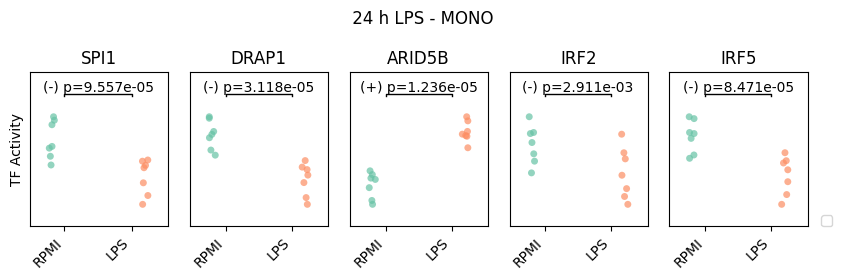

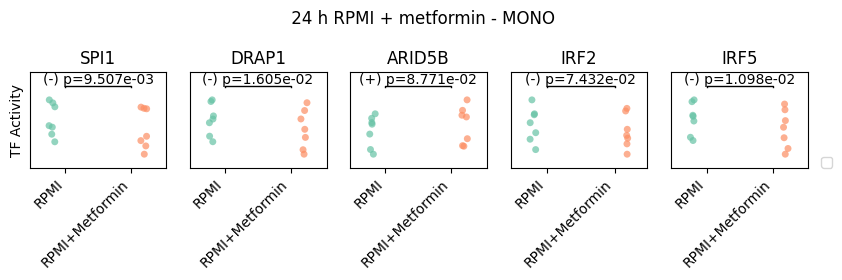

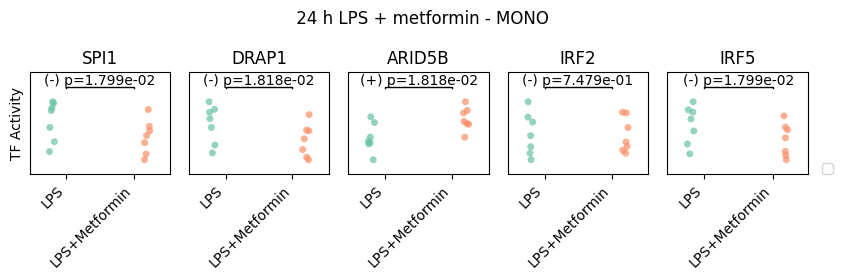

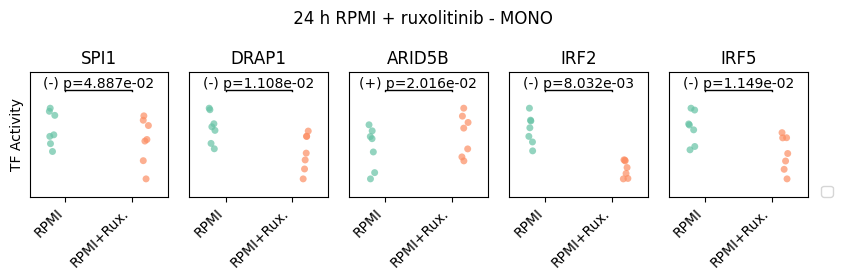

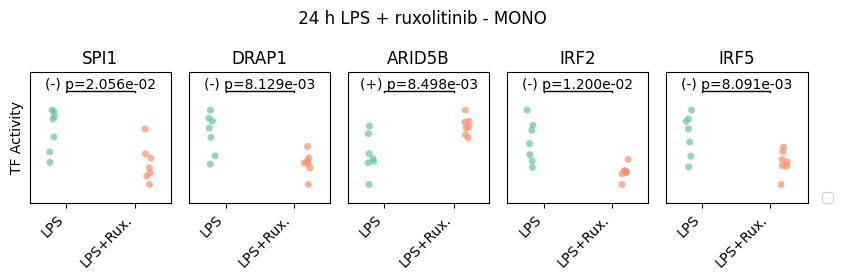

In [13]:
from ciim.src.tf_activity.plots import plot_ctr_condition_distribution

# features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']
features = ['SPI1', 'DRAP1', 'ARID5B', 'IRF2', 'IRF5']

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h LPS', '24 h LPS + metformin'),

                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                ('24 h LPS', '24 h LPS + ruxolitinib')
                ]
for ctr, treatment in experiments:
    plot_ctr_condition_distribution(['MONO'], features, treatment, ctr, dataset, type=type, feature_type=feature_type, 
                                    map_names=pretty_names, 
                                    stats=stats_all.rename(columns={'tf':'gene', 'target':'gene'}))




# Trajectory plot: TF acitvity with age


(3324, 116)
(313, 273)
(253, 239)
(150, 102)
(3324,) (3324,) (3324,)
(313,) (313,) (313,)
(253,) (253,) (253,)
(150,) (150,) (150,)


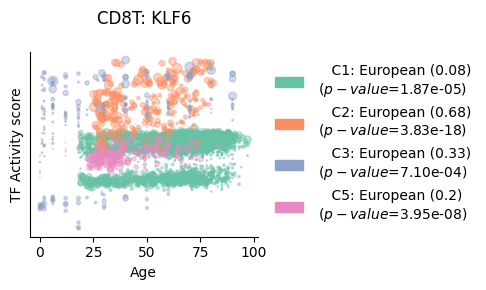

In [14]:

from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata_bulk(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'../output/tf_activity/trends_{cell_type}_case.png', dpi=300)

In [15]:
data_df['cohort'].unique()

NameError: name 'data_df' is not defined

Spearman correlations per cohort:

Meta-analysis combined p-value (Fisher's method): 6.258559317395964e-94


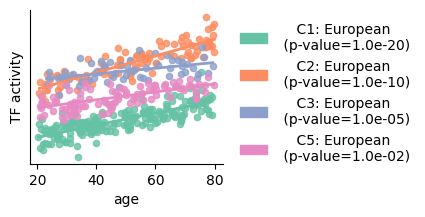

In [51]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, combine_pvalues
import matplotlib.pyplot as plt

# Step 1: Generate random data
np.random.seed(42)  # for reproducibility

n_samples_list = [200, 100, 60, 100]  # number of samples per cohort
cohorts = datasets_e

data = []

# Define base slope and intercept
base_slope = 0.05
base_intercept = 0.5

for i,cohort in enumerate(cohorts):
    n_samples = n_samples_list[i]
    ages = np.random.uniform(20, 80, size=n_samples)
    
    # Slight random shifts in slope and intercept for each cohort
    slope_shift = np.random.normal(0, 0.02)
    intercept_shift = np.random.normal(0, 4)
    
    tf_activity = (base_slope + slope_shift) * ages + (base_intercept + intercept_shift)
    tf_activity += np.random.normal(0, 0.5, size=n_samples)  # add noise
    
    cohort_df = pd.DataFrame({
        'cohort': cohort,
        'age': ages,
        'tf_activity': tf_activity
    })
    
    data.append(cohort_df)

# Combine into one dataframe
data_df = pd.concat(data, ignore_index=True)
data_df['cohort'] = data_df['cohort'].astype(pd.CategoricalDtype(categories=cohorts, ordered=True))
# Step 2: Calculate Spearman correlation per cohort
results = []
for cohort in cohorts:
    subset = data_df[data_df['cohort'] == cohort]
    corr, pval = spearmanr(subset['age'], subset['tf_activity'])
    results.append({'cohort': cohort, 'spearman_corr': corr, 'pval': pval})

results_df = pd.DataFrame(results)
print("Spearman correlations per cohort:")
_, combined_pval = combine_pvalues(results_df['pval'])

print("\nMeta-analysis combined p-value (Fisher's method):", combined_pval)

# (Optional) Step 4: Plotting
import seaborn as sns
fig, ax = plt.subplots(figsize=(2.5, 2))
for cohort in data_df['cohort'].unique():
    subset = data_df[data_df['cohort'] == cohort]
    sns.regplot(data=subset, x='age', y='tf_activity', ax=ax, 
                scatter_kws={'s': 20}, line_kws={'linewidth':2},
                color=palette_datasets[cohort], label=cohort, ci=None)

# ax.legend(title='Cohort', loc=(1.1, .2), frameon=False)
p_values = [1E-20, 1E-10, 1E-5, 1E-2]
legend_handles = []
for i, d in enumerate(cohorts):
    p_value = p_values[i]
    legend_label = '    ' + surrogate_names[d] +'\n' + r' (p-value=' + "{:.1e}".format(p_value) + ")"

    handle = mpatches.Patch(color=palette_datasets[d], label=legend_label)
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_yticks([])
ax.set_ylabel('TF activity')
plt.show()

## TF activity trend vs expression trend in aging


In [52]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, retrieve_adata_bulk

stats_store = []
for dataset in datasets:
    adata = retrieve_adata_bulk(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activity/activation_vs_expression.png', dpi=300)

ImportError: cannot import name 'determine_stats' from 'ciim.src.tf_activity.helper' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/helper.py)